# Criação do Qubit e esfera de bloch

In [ ]:
%pip install qiskit[visualization]==1.2.2
%pip install qiskit_aer
%pip install qiskit_ibm_runtime
%pip install matplotlib

In [6]:
import qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from math import sqrt
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram


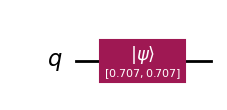

In [ ]:
# Criando um circuito quântico com um qubit
qubit = QuantumRegister(1, 'q')
circuito = QuantumCircuit(1)

# Inicializando o estado do qubit
alpha = 1/sqrt(2)  
beta = 1/sqrt(2) 

# O estado do qubit é representado como uma combinação linear dos estados |0⟩ e |1⟩, onde alpha é a amplitude do estado |0⟩ e beta é a amplitude do estado |1⟩. A soma dos quadrados das amplitudes deve ser igual a 1 para garantir que o estado seja normalizado.
psi = [alpha, beta]
circuito.initialize(psi, qubit[0])

circuito.draw('mpl') # Desenhar o circuito usando Matplotlib

In [13]:
psi = qi.Statevector.from_instruction(circuito) # Obter o estado do qubit após a inicialização
print(psi)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [ ]:
prob = psi.probabilities() # Calcular as probabilidades de medir o estado |0⟩ e o estado |1⟩
print(prob)

[0.5 0.5]


Nesse caso tem 50% para cada estado

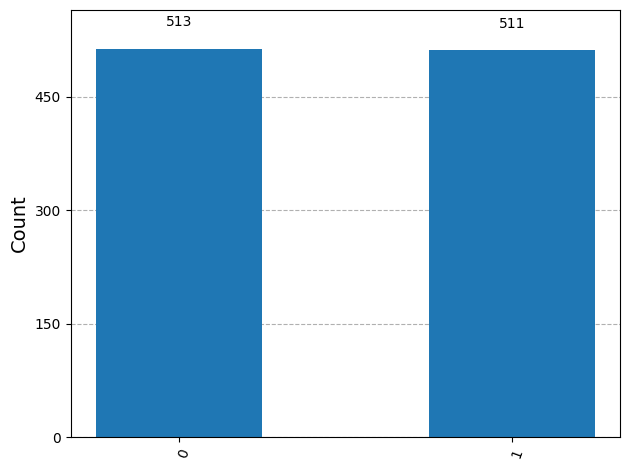

In [ ]:
cont = psi.sample_counts(shots=1024) # Gerar uma amostra de medidas do estado do qubit. O método sample_counts simula a medição do estado do qubit várias vezes (neste caso, 1024 vezes) e retorna um dicionário com as contagens de cada resultado possível (|0⟩ ou |1⟩).
plot_histogram(cont)

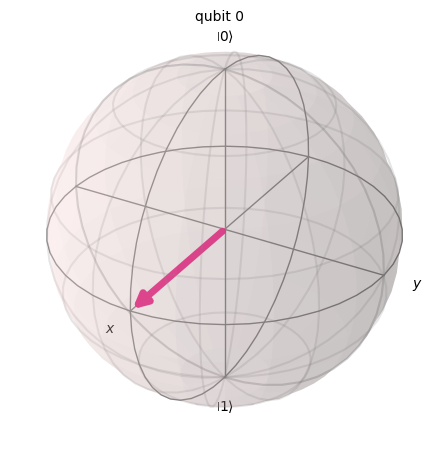

In [ ]:
psi.draw('bloch') # Visualizar o estado do qubit na esfera de Bloch.

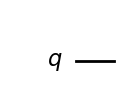

In [15]:
quantum_circuito = QuantumCircuit(1)
quantum_circuito.draw('mpl')

In [19]:
psi2 = qi.Statevector(quantum_circuito) # Obter o estado do qubit a partir do circuito quântico
print(psi2)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [ ]:
prob2 = psi2.probabilities() # Nesse caso vai ter mais probabilidade de medir o estado |0⟩ do que o estado |1⟩, porque o estado do qubit foi inicializado para estar mais próximo do estado |0⟩ na esfera de Bloch.
print(prob2)

[1. 0.]


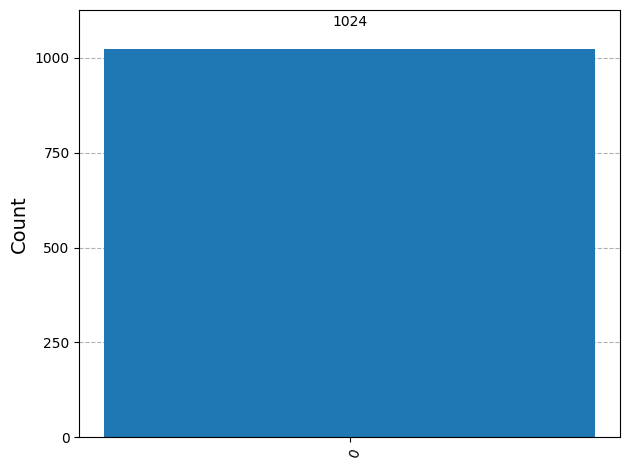

In [21]:
cont2 = psi2.sample_counts(shots=1024) # Gerar uma amostra de medidas do estado do qubit a partir do segundo estado
plot_histogram(cont2)

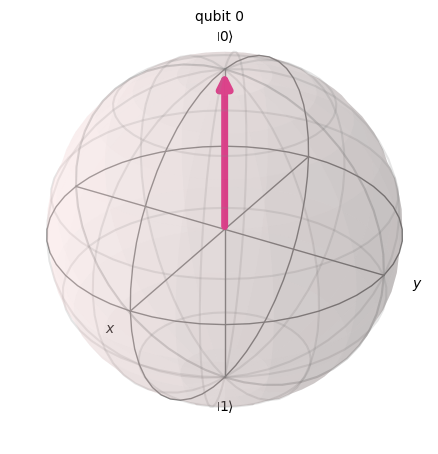

In [22]:
psi2.draw('bloch')